# S09_evalue

Sensitivity analysis for unmeasured confounding using E-values
Consistent with Firth-based primary/secondary models from S05-S08

## Imports

In [ ]:
import json
import math
from pathlib import Path
from typing import Optional, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Config

In [ ]:
CONFIG_SNAPSHOT = Path("/mnt/data/config_snapshot.json")
if not CONFIG_SNAPSHOT.exists():
    CONFIG_SNAPSHOT = Path("/content/reports/config_snapshot.json")
if not CONFIG_SNAPSHOT.exists():
    CONFIG_SNAPSHOT = Path("/content/config_snapshot.json")
if not CONFIG_SNAPSHOT.exists():
    raise FileNotFoundError("config_snapshot.json not found. Upload it or run S00 first.")

with open(CONFIG_SNAPSHOT, "r", encoding="utf-8") as f:
    CFG = json.load(f)

## Directories and logging

In [ ]:
tables_dir = Path(CFG["paths"]["tables_dir"])
figures_dir = Path(CFG["paths"]["figures_dir"])
reports_dir = Path(CFG["paths"]["reports_dir"])
supplementary_dir = Path(CFG["paths"].get("supplementary_dir", tables_dir))

tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)
supplementary_dir.mkdir(parents=True, exist_ok=True)

PRIMARY_MODEL_KIND = str(CFG["analysis"].get("primary_binary_model", "unknown")).lower()
SECONDARY_MODEL_KIND = str(CFG["analysis"].get("secondary_binary_model", "unknown")).lower()
RARE_EVENT_THRESHOLD = int(CFG["analysis"].get("rare_event_warning_threshold", 10))

print("Loaded config snapshot:", CONFIG_SNAPSHOT)
print("tables_dir:", tables_dir)
print("figures_dir:", figures_dir)
print("reports_dir:", reports_dir)
print("supplementary_dir:", supplementary_dir)
print("primary_binary_model:", PRIMARY_MODEL_KIND)
print("secondary_binary_model:", SECONDARY_MODEL_KIND)
print("rare_event_warning_threshold:", RARE_EVENT_THRESHOLD)

Loaded config snapshot: /content/config_snapshot.json
tables_dir: /content/outputs/tables
figures_dir: /content/outputs/figures
reports_dir: /content/reports
supplementary_dir: /content/outputs/supplementary
primary_binary_model: firth
secondary_binary_model: firth
rare_event_warning_threshold: 10


## E-value functions

In [ ]:
def _evalue_from_rr(rr: float) -> float:
    """
    Standard E-value formula for RR >= 1:
        E = RR + sqrt(RR * (RR - 1))
    For protective associations (RR < 1), the reciprocal is used.
    """
    if not np.isfinite(rr) or rr <= 0:
        return np.nan

    rr = float(rr)
    if rr < 1:
        rr = 1.0 / rr

    if rr <= 1:
        return 1.0

    return float(rr + np.sqrt(rr * (rr - 1.0)))


def evalue_or(or_value: float) -> float:
    """
    Approximate E-value computed by applying the RR-based formula to OR.
    This is acceptable as a transparent approximation, especially when outcomes are rare,
    but should be interpreted cautiously for non-rare outcomes.
    """
    if not np.isfinite(or_value) or or_value <= 0:
        return np.nan
    return _evalue_from_rr(float(or_value))


def evalue_ci(or_value: float, ci_low: float, ci_high: float) -> float:
    """
    E-value for the CI limit closest to the null (1.0).
    If the confidence interval includes 1.0, E-value for the CI is 1.0 by definition.
    """
    vals = [or_value, ci_low, ci_high]
    if not all(np.isfinite(vals)) or min(ci_low, ci_high) <= 0:
        return np.nan

    lo = min(float(ci_low), float(ci_high))
    hi = max(float(ci_low), float(ci_high))

    if lo <= 1.0 <= hi:
        return 1.0

    closest_to_null = lo if abs(lo - 1.0) < abs(hi - 1.0) else hi
    return _evalue_from_rr(float(closest_to_null))

## Helpers

In [ ]:
def _find_first_existing(candidates: List[Path]) -> Optional[Path]:
    for p in candidates:
        if p.exists():
            return p
    return None


def _standardize_cols(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]
    return out


def _pick_col(df: pd.DataFrame, options: List[str]) -> Optional[str]:
    lower = {str(c).strip().lower(): c for c in df.columns}
    for opt in options:
        key = str(opt).strip().lower()
        if key in lower:
            return lower[key]
    return None


def _coerce_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")

## Searching for input tables

In [ ]:
primary_candidates = [
    tables_dir / "Table2_primary_model.csv",
    tables_dir / "Table1_primary_model.csv",
    supplementary_dir / "Table2_primary_model.csv",
    supplementary_dir / "Table1_primary_model.csv",
    Path("/mnt/data/Table2_primary_model.csv"),
    Path("/mnt/data/Table1_primary_model.csv"),
    Path("/content/Table2_primary_model.csv"),
    Path("/content/Table1_primary_model.csv"),
]

secondary_candidates = [
    tables_dir / "Table3_secondary_models.csv",
    supplementary_dir / "Table3_secondary_models.csv",
    Path("/mnt/data/Table3_secondary_models.csv"),
    Path("/content/Table3_secondary_models.csv"),
]

primary_path = _find_first_existing(primary_candidates)
secondary_path = _find_first_existing(secondary_candidates)

if primary_path is None:
    raise FileNotFoundError(
        "Primary model table not found. Expected one of: "
        "Table2_primary_model.csv or Table1_primary_model.csv"
    )

df_primary = _standardize_cols(pd.read_csv(primary_path))
print("Loaded primary:", primary_path, "shape:", df_primary.shape)

df_secondary = None
if secondary_path is not None:
    df_secondary = _standardize_cols(pd.read_csv(secondary_path))
    print("Loaded secondary:", secondary_path, "shape:", df_secondary.shape)
else:
    print("Secondary table not found — S09 will run on primary model only.")

Loaded primary: /content/Table2_primary_model.csv shape: (3, 24)
Loaded secondary: /content/Table3_secondary_models.csv shape: (6, 27)


## Primary parsing

In [ ]:
term_col_p = _pick_col(df_primary, ["term", "variable", "predictor"])
or_col_p = _pick_col(df_primary, ["OR", "or", "or_tai", "or_tai_a"])
lo_col_p = _pick_col(df_primary, ["CI_low", "ci_low", "lower", "ci_lower"])
hi_col_p = _pick_col(df_primary, ["CI_high", "ci_high", "upper", "ci_upper"])
outcome_col_p = _pick_col(df_primary, ["outcome", "endpoint", "model", "dependent"])
events_col_p = _pick_col(df_primary, ["events_exposed", "n_events_exposed", "event_exposed", "tai_pos_events"])
nexp_col_p = _pick_col(df_primary, ["n_exposed", "n_tai_pos", "tai_pos_n"])
total_events_col_p = _pick_col(df_primary, ["events_total", "n_events_total", "total_events"])

if term_col_p is None or or_col_p is None or lo_col_p is None or hi_col_p is None:
    raise KeyError(f"Primary table missing required columns. Found: {list(df_primary.columns)}")

dfp = df_primary.copy()
dfp["_term_l"] = dfp[term_col_p].astype(str).str.strip().str.lower()

tai_terms_exact = {
    "tai",
    "tai_a",
    "tai_a (tai)",
    "tai_a ",
    "exposure_tai",
    "tai_positive",
}
dfp_tai = dfp[dfp["_term_l"].isin(tai_terms_exact)].copy()

if dfp_tai.empty:
    dfp_tai = dfp[dfp["_term_l"].str.contains("tai", na=False)].copy()

if dfp_tai.empty:
    raise ValueError("Could not find TAI term row in primary model table.")

# prefer the first matching TAI row
dfp_tai = dfp_tai.head(1).copy()

primary_outcome_name = "primary_endpoint"
if outcome_col_p is not None:
    primary_outcome_name = str(dfp_tai[outcome_col_p].iloc[0]).strip()

primary_or = float(dfp_tai[or_col_p].iloc[0])
primary_lo = float(dfp_tai[lo_col_p].iloc[0])
primary_hi = float(dfp_tai[hi_col_p].iloc[0])

primary_row = {
    "endpoint": primary_outcome_name,
    "model_set": "primary",
    "term": str(dfp_tai[term_col_p].iloc[0]),
    "effect_measure": "OR",
    "estimator": PRIMARY_MODEL_KIND,
    "OR": primary_or,
    "CI_low": primary_lo,
    "CI_high": primary_hi,
    "ci_includes_null": bool(primary_lo <= 1.0 <= primary_hi),
    "effect_direction": "lower_odds_in_TAI_positive" if primary_or < 1 else "higher_odds_in_TAI_positive",
    "events_exposed": float(dfp_tai[events_col_p].iloc[0]) if events_col_p is not None else np.nan,
    "n_exposed": float(dfp_tai[nexp_col_p].iloc[0]) if nexp_col_p is not None else np.nan,
    "events_total": float(dfp_tai[total_events_col_p].iloc[0]) if total_events_col_p is not None else np.nan,
}

primary_row

{'endpoint': 'Primary: Firth logistic (ep_primary ~ TAI_A + age_c)',
 'model_set': 'primary',
 'term': 'TAI_A',
 'effect_measure': 'OR',
 'estimator': 'firth',
 'OR': 0.7658349805993099,
 'CI_low': 0.2108528694966625,
 'CI_high': 1.66581638021192,
 'ci_includes_null': True,
 'effect_direction': 'lower_odds_in_TAI_positive',
 'events_exposed': nan,
 'n_exposed': 84.0,
 'events_total': nan}

## Secondary parsing

In [ ]:
secondary_rows = []

if df_secondary is not None:
    term_col_s = _pick_col(df_secondary, ["term", "variable", "predictor"])
    or_col_s = _pick_col(df_secondary, ["OR", "or", "or_tai", "or_tai_a"])
    lo_col_s = _pick_col(df_secondary, ["CI_low", "ci_low", "lower", "ci_lower"])
    hi_col_s = _pick_col(df_secondary, ["CI_high", "ci_high", "upper", "ci_upper"])
    outcome_col_s = _pick_col(df_secondary, ["outcome", "endpoint", "model", "dependent"])
    events_col_s = _pick_col(df_secondary, ["events_exposed", "n_events_exposed", "event_exposed", "tai_pos_events"])
    nexp_col_s = _pick_col(df_secondary, ["n_exposed", "n_tai_pos", "tai_pos_n"])
    total_events_col_s = _pick_col(df_secondary, ["events_total", "n_events_total", "total_events"])

    if term_col_s is None or or_col_s is None or lo_col_s is None or hi_col_s is None:
        raise KeyError(f"Secondary table missing required columns. Found: {list(df_secondary.columns)}")

    dfs = df_secondary.copy()
    dfs["_term_l"] = dfs[term_col_s].astype(str).str.strip().str.lower()

    dfs_tai = dfs[dfs["_term_l"].isin(tai_terms_exact)].copy()
    if dfs_tai.empty:
        dfs_tai = dfs[dfs["_term_l"].str.contains("tai", na=False)].copy()

    if dfs_tai.empty:
        print("Warning: Could not find TAI rows in secondary table; skipping.")
    else:
        for _, r in dfs_tai.iterrows():
            endpoint = str(r[outcome_col_s]).strip() if outcome_col_s is not None else "secondary_endpoint"
            or_val = float(r[or_col_s])
            lo_val = float(r[lo_col_s])
            hi_val = float(r[hi_col_s])

            secondary_rows.append({
                "endpoint": endpoint,
                "model_set": "secondary",
                "term": str(r[term_col_s]),
                "effect_measure": "OR",
                "estimator": SECONDARY_MODEL_KIND,
                "OR": or_val,
                "CI_low": lo_val,
                "CI_high": hi_val,
                "ci_includes_null": bool(lo_val <= 1.0 <= hi_val),
                "effect_direction": "lower_odds_in_TAI_positive" if or_val < 1 else "higher_odds_in_TAI_positive",
                "events_exposed": float(r[events_col_s]) if events_col_s is not None and pd.notna(r[events_col_s]) else np.nan,
                "n_exposed": float(r[nexp_col_s]) if nexp_col_s is not None and pd.notna(r[nexp_col_s]) else np.nan,
                "events_total": float(r[total_events_col_s]) if total_events_col_s is not None and pd.notna(r[total_events_col_s]) else np.nan,
            })

print("Secondary TAI rows collected:", len(secondary_rows))
secondary_rows[:3]

Secondary TAI rows collected: 2


[{'endpoint': 'ep_non_hdl',
  'model_set': 'secondary',
  'term': 'TAI_A',
  'effect_measure': 'OR',
  'estimator': 'firth',
  'OR': 1.0912202311240955,
  'CI_low': 0.6116881886188331,
  'CI_high': 1.7630873053904657,
  'ci_includes_null': True,
  'effect_direction': 'higher_odds_in_TAI_positive',
  'events_exposed': nan,
  'n_exposed': 84.0,
  'events_total': nan},
 {'endpoint': 'ep_ogtt120',
  'model_set': 'secondary',
  'term': 'TAI_A',
  'effect_measure': 'OR',
  'estimator': 'firth',
  'OR': 1.265196713498669,
  'CI_low': 0.6251808771056044,
  'CI_high': 2.1802891511462805,
  'ci_includes_null': True,
  'effect_direction': 'higher_odds_in_TAI_positive',
  'events_exposed': nan,
  'n_exposed': 79.0,
  'events_total': nan}]

## E-value calculation and table entry

In [ ]:
def _short_endpoint_label(x: str) -> str:
    s = str(x).strip()

    mapping = {
        "ep_primary": "TG/HDL > 3.5",
        "ep_non_hdl": "non-HDL > 130 mg/dL",
        "ep_ogtt120": "OGTT 120 min >= 140 mg/dL",
    }

    if s in mapping:
        return mapping[s]

    s_low = s.lower()
    if "ep_primary" in s_low or "tg" in s_low and "hdl" in s_low:
        return "TG/HDL > 3.5"
    if "ep_non_hdl" in s_low or "non_hdl" in s_low or "non-hdl" in s_low:
        return "non-HDL > 130 mg/dL"
    if "ep_ogtt120" in s_low or "ogtt" in s_low or "glu120" in s_low:
        return "OGTT 120 min >= 140 mg/dL"

    return s

In [ ]:
rows = [primary_row] + secondary_rows
res = pd.DataFrame(rows)

if res.empty:
    raise ValueError("No model rows available for E-value calculation.")

for col in ["OR", "CI_low", "CI_high", "events_exposed", "n_exposed", "events_total"]:
    if col in res.columns:
        res[col] = _coerce_numeric(res[col])

res["E_value_point"] = res["OR"].apply(evalue_or)
res["E_value_CI"] = res.apply(
    lambda r: evalue_ci(r["OR"], r["CI_low"], r["CI_high"]),
    axis=1
)

res["endpoint_label"] = res["endpoint"].apply(_short_endpoint_label)

res["rare_event_warning"] = np.where(
    res["events_exposed"].notna() & (res["events_exposed"] < RARE_EVENT_THRESHOLD),
    True,
    False
)

res["interpretation_caution"] = np.where(
    res["ci_includes_null"],
    "CI includes 1.0; E-value for CI is not informative beyond the null-compatible result",
    np.where(
        res["rare_event_warning"],
        "Rare events in exposed group; interpret E-value cautiously",
        ""
    )
)

res["model_rank"] = res["model_set"].map({"primary": 0, "secondary": 1}).fillna(9).astype(int)
res = res.sort_values(["model_rank", "endpoint_label"]).drop(columns=["model_rank"]).reset_index(drop=True)

out_table = supplementary_dir / "TableS2_Evalues.csv"
res.to_csv(out_table, index=False)

print("Saved:", out_table)
res

Saved: /content/outputs/supplementary/TableS2_Evalues.csv


,endpoint,model_set,term,effect_measure,estimator,OR,CI_low,CI_high,ci_includes_null,effect_direction,events_exposed,n_exposed,events_total,E_value_point,E_value_CI,endpoint_label,rare_event_warning,interpretation_caution
0,Primary: Firth logistic (ep_primary ~ TAI_A + ...,primary,TAI_A,OR,firth,0.765835,0.210853,1.665816,True,lower_odds_in_TAI_positive,NaN,84.0,NaN,1.937632,1.0,TG/HDL > 3.5,False,CI includes 1.0; E-value for CI is not informa...
1,ep_ogtt120,secondary,TAI_A,OR,firth,1.265197,0.625181,2.180289,True,higher_odds_in_TAI_positive,NaN,79.0,NaN,1.844443,1.0,OGTT 120 min >= 140 mg/dL,False,CI includes 1.0; E-value for CI is not informa...
2,ep_non_hdl,secondary,TAI_A,OR,firth,1.091220,0.611688,1.763087,True,higher_odds_in_TAI_positive,NaN,84.0,NaN,1.406722,1.0,non-HDL > 130 mg/dL,False,CI includes 1.0; E-value for CI is not informa...


## Figures

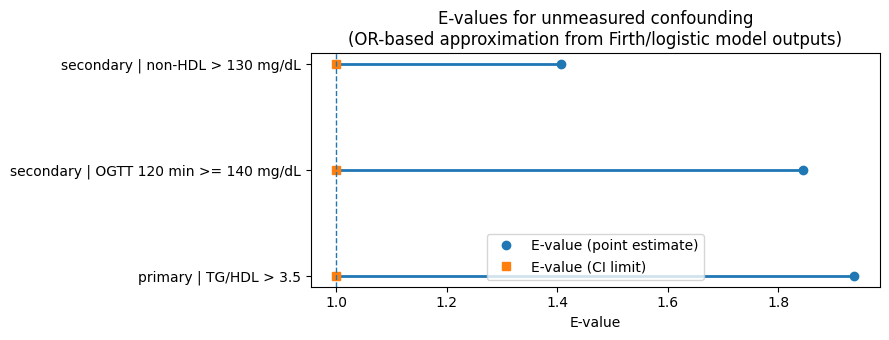

Saved: /content/outputs/figures/F10_Evalues.png


In [ ]:
plot_df = res.copy().sort_values(["model_set", "endpoint_label"]).reset_index(drop=True)

y_labels = [
    f"{r['model_set']} | {r['endpoint_label']}"
    for _, r in plot_df.iterrows()
]
y = np.arange(len(plot_df))

plt.figure(figsize=(9, max(3.5, 0.45 * len(plot_df))))
plt.hlines(y, xmin=1.0, xmax=plot_df["E_value_point"], linewidth=2)
plt.plot(plot_df["E_value_point"], y, marker="o", linestyle="None", label="E-value (point estimate)")
plt.plot(plot_df["E_value_CI"], y, marker="s", linestyle="None", label="E-value (CI limit)")

plt.axvline(1.0, linestyle="--", linewidth=1)
plt.yticks(y, y_labels)
plt.xlabel("E-value")
plt.title("E-values for unmeasured confounding\n(OR-based approximation from Firth/logistic model outputs)")
plt.legend()
plt.tight_layout()

out_fig = figures_dir / "F10_Evalues.png"
plt.savefig(out_fig, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out_fig)

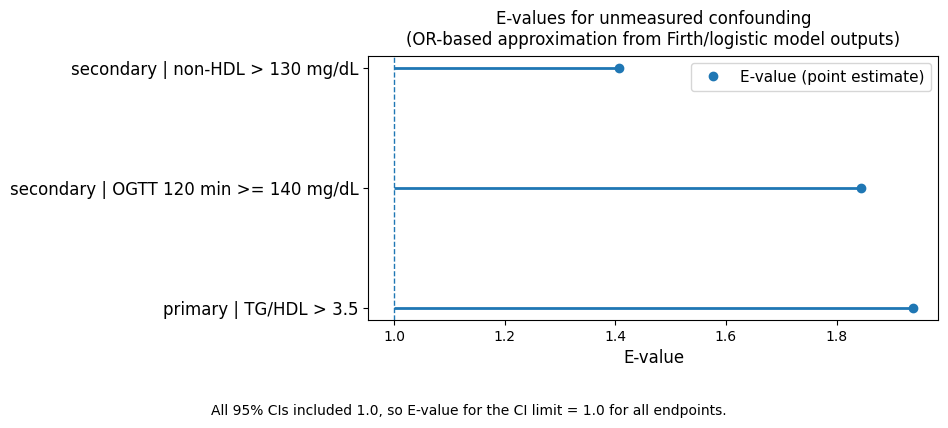

Saved: /content/outputs/figures/F10_Evalues.png


In [ ]:
plot_df = res.copy().sort_values(["model_set", "endpoint_label"]).reset_index(drop=True)

y_labels = [f"{r['model_set']} | {r['endpoint_label']}" for _, r in plot_df.iterrows()]
y = np.arange(len(plot_df))

show_ci_points = (plot_df["E_value_CI"] > 1.0).any()

fig, ax = plt.subplots(figsize=(10, 4.8))

ax.hlines(y, xmin=1.0, xmax=plot_df["E_value_point"], linewidth=2)
ax.plot(
    plot_df["E_value_point"],
    y,
    marker="o",
    linestyle="None",
    label="E-value (point estimate)"
)

if show_ci_points:
    ax.plot(
        plot_df["E_value_CI"],
        y,
        marker="s",
        linestyle="None",
        label="E-value (CI limit)"
    )

ax.axvline(1.0, linestyle="--", linewidth=1)

ax.set_yticks(y)
ax.set_yticklabels(y_labels, fontsize=12)
ax.set_xlabel("E-value", fontsize=12)
ax.set_title(
    "E-values for unmeasured confounding\n"
    "(OR-based approximation from Firth/logistic model outputs)",
    fontsize=12,
    pad=8
)

if show_ci_points:
    ax.legend(loc="upper right", fontsize=11)
else:
    ax.legend(loc="upper right", fontsize=11)


fig.subplots_adjust(
    left=0.40,
    right=0.97,
    top=0.82,
    bottom=0.27
)

if not show_ci_points:
    fig.text(
        0.5,
        0.08,
        "All 95% CIs included 1.0, so E-value for the CI limit = 1.0 for all endpoints.",
        ha="center",
        va="center",
        fontsize=10
    )

out_fig = figures_dir / "F10_Evalues.png"
fig.savefig(out_fig, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out_fig)

## Notes

In [ ]:
note = []
note.append("Sensitivity analysis using E-values")
note.append("")
note.append("E-values quantify the minimum strength of association that an unmeasured confounder")
note.append("would need to have with both the exposure (TAI) and the outcome to explain away")
note.append("the observed association, conditional on measured covariates.")
note.append("")
note.append("Important interpretation notes for this project:")
note.append("1. E-values were calculated from odds ratios using an RR-based approximation.")
note.append("2. The primary and secondary binary models in this pipeline are Firth logistic models,")
note.append("   selected because of sparse data / rare events.")
note.append("3. If a 95% CI includes 1.0, the E-value for the CI limit is 1.0 by definition.")
note.append("4. E-values do not resolve limitations due to cross-sectional design, residual selection issues,")
note.append("   or unavailable adiposity measures (e.g., BMI), and therefore should be interpreted as")
note.append("   a supplementary sensitivity analysis rather than proof of causal robustness.")
note.append("5. Rare events in the exposed group further limit precision of both effect estimates and E-values.")

out_note = reports_dir / "S09_evalue_note.txt"
out_note.write_text("\n".join(note), encoding="utf-8")

print("Saved:", out_note)
print("\n".join(note))

Saved: /content/reports/S09_evalue_note.txt
Sensitivity analysis using E-values

E-values quantify the minimum strength of association that an unmeasured confounder
would need to have with both the exposure (TAI) and the outcome to explain away
the observed association, conditional on measured covariates.

Important interpretation notes for this project:
1. E-values were calculated from odds ratios using an RR-based approximation.
2. The primary and secondary binary models in this pipeline are Firth logistic models,
   selected because of sparse data / rare events.
3. If a 95% CI includes 1.0, the E-value for the CI limit is 1.0 by definition.
4. E-values do not resolve limitations due to cross-sectional design, residual selection issues,
   or unavailable adiposity measures (e.g., BMI), and therefore should be interpreted as
   a supplementary sensitivity analysis rather than proof of causal robustness.
5. Rare events in the exposed group further limit precision of both effect estimat

E-values ranged from 1.4 to 1.9 across endpoints, indicating that only modest unmeasured confounding would be required to explain away the observed associations.